<a href="https://colab.research.google.com/github/Chagaiz28/AG2/blob/Projetps/lista2/Questao5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício 5 — Gradiente Descendente: Batch, Estocástico e Mini-batch

Neste exercício implementamos e comparamos os três tipos de algoritmo de gradiente descendente:
- **(a/b)** Implementação do **Mini-batch GD**
- **(c)** Superfície de erro, contorno e curva erro × iteração
- **(d)** Busca manual do passo de aprendizagem ótimo
- **(e)** Comparação com Batch GD e SGD
- **(f)** Conclusões

**Função objetivo:** $y = 2x_1 + 2x_2 + w$, com $x_1, x_2, w \sim \mathcal{N}(0,1)$, $N = 1000$ amostras.

**Função hipótese:** $\hat{y} = h(\mathbf{x}) = \hat{a}_1 x_1 + \hat{a}_2 x_2$

## Importando bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import random

## Definição de funções auxiliares

Funções reutilizadas pelos três algoritmos: cálculo da superfície de erro, equação normal e os três algoritmos de GD.

In [1]:
def calculateErrorSurface(x1, x2, y):

    N = len(y)
    M = 200
    a1 = np.linspace(-2.0, 6.0, M)
    a2 = np.linspace(-2.0, 6.0, M)
    A1, A2 = np.meshgrid(a1, a2)
    J = np.zeros((M, M))
    for iter1 in range(M):
        for iter2 in range(M):
            yhat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2
            J[iter1, iter2] = (1.0/N)*np.sum(np.square(y - yhat))
    return J, A1, A2


def calculateClosedFormSolution(X, y):

    N = len(y)
    a_opt = np.linalg.pinv(X.T.dot(X)).dot(X.T.dot(y))
    yhat = X.dot(a_opt)
    Joptimum = (1.0/N)*np.sum(np.power((y - yhat), 2))
    return Joptimum, a_opt


# ------------------------------------------------------------------ #
#  BATCH GRADIENT DESCENT
# ------------------------------------------------------------------ #
def batchGradientDescent(X, y, alpha, n_iterations):

    N = len(y)
    a = np.array([-10.0, -10.0]).reshape(2, 1)

    a_hist  = np.zeros((2, n_iterations+1))
    a_hist[:, 0] = a.reshape(2,)
    Jgd     = np.zeros(n_iterations+1)
    Jgd[0]  = (1.0/N)*np.sum(np.power(y - X.dot(a), 2))
    grad_hist = np.zeros((2, n_iterations))

    for iteration in range(n_iterations):
        gradients = -(2.0/N)*X.T.dot(y - X.dot(a))
        a = a - alpha * gradients
        Jgd[iteration+1]          = (1.0/N)*np.sum(np.power((y - X.dot(a)), 2))
        a_hist[:, iteration+1]    = a.reshape(2,)
        grad_hist[:, iteration]   = gradients.reshape(2,)

    return a, a_hist, Jgd, grad_hist


# ------------------------------------------------------------------ #
#  STOCHASTIC GRADIENT DESCENT (SGD)
# ------------------------------------------------------------------ #
def stocasticGradientDescent(X, y, alpha, n_epochs):

    N = len(y)
    a = np.array([-10.0, -10.0]).reshape(2, 1)

    a_hist  = np.zeros((2, n_epochs*N+1))
    a_hist[:, 0] = a.reshape(2,)
    Jgd     = np.zeros(n_epochs*N+1)
    Jgd[0]  = (1.0/N)*np.sum(np.power(y - X.dot(a), 2))
    grad_hist   = np.zeros((2, n_epochs*N))
    update_hist = np.zeros((2, n_epochs*N))

    for epoch in range(n_epochs):
        shuffled_indexes = random.sample(range(N), N)
        for i in range(N):
            idx = shuffled_indexes[i]
            xi  = X[idx:idx+1]
            yi  = y[idx:idx+1]

            gradient = -2.0*xi.T.dot(yi - xi.dot(a))
            update   = alpha * gradient
            a        = a - update

            pos = epoch*N + i
            Jgd[pos+1]          = (1.0/N)*np.sum(np.power((y - X.dot(a)), 2))
            grad_hist[:, pos]   = gradient.reshape(2,)
            update_hist[:, pos] = update.reshape(2,)
            a_hist[:, pos+1]    = a.reshape(2,)

    return a, a_hist, Jgd, grad_hist, update_hist


# ------------------------------------------------------------------ #
#  MINI-BATCH GRADIENT DESCENT
# ------------------------------------------------------------------ #
def miniBatchGradientDescent(X, y, alpha, n_epochs, batch_size):
    N = len(y)

    n_batches = N // batch_size

    # Total de iterações = épocas × mini-batches por época
    total_iters = n_epochs * n_batches

    a = np.array([-10.0, -10.0]).reshape(2, 1)

    # Estruturas para armazenar o histórico.
    a_hist    = np.zeros((2, total_iters+1))
    a_hist[:, 0] = a.reshape(2,)
    Jgd       = np.zeros(total_iters+1)
    Jgd[0]    = (1.0/N)*np.sum(np.power(y - X.dot(a), 2))
    grad_hist = np.zeros((2, total_iters))

    iteration = 0   # contador global de iterações (mini-batch)

    for epoch in range(n_epochs):


        shuffled_indexes = np.random.permutation(N)

        for batch in range(n_batches):

            batch_indexes = shuffled_indexes[batch*batch_size : (batch+1)*batch_size]
            X_batch = X[batch_indexes]
            y_batch = y[batch_indexes]


            gradient = -(2.0/batch_size)*X_batch.T.dot(y_batch - X_batch.dot(a))

            # Atualiza os pesos.
            a = a - alpha * gradient


            Jgd[iteration+1]          = (1.0/N)*np.sum(np.power((y - X.dot(a)), 2))
            a_hist[:, iteration+1]    = a.reshape(2,)
            grad_hist[:, iteration]   = gradient.reshape(2,)

            iteration += 1

    return a, a_hist, Jgd, grad_hist

---
## (b) Gerando o conjunto de dados

**Função objetivo:** $y = 2x_1 + 2x_2 + w$, com $x_1, x_2, w \sim \mathcal{N}(0,1)$ e $N = 1000$ amostras.

In [3]:
# Reset the pseudo random number generator to the same value.
seed = 1012019
np.random.seed(seed)
random.seed(seed)

N = 1000

# Features.
x1 = np.random.randn(N, 1)
x2 = np.random.randn(N, 1)

y = 2.0*x1 + 2.0*x2

w = np.random.randn(N, 1)

y_noisy = y + w

X = np.c_[x1, x2]

### Equação normal — solução ótima (referência)

In [4]:
# Closed-form solution (normal equation).
Joptimum, a_opt = calculateClosedFormSolution(X, y_noisy)

print('--- Equação Normal (solução ótima) ---')
print(f'a1_opt: {a_opt[0, 0]:.6f}')
print(f'a2_opt: {a_opt[1, 0]:.6f}')
print(f'MSE ótimo: {Joptimum:.6f}')

--- Equação Normal (solução ótima) ---
a1_opt: 2.039131
a2_opt: 2.019523
MSE ótimo: 0.969222


---
## (c) Superfície de erro e contorno (Mini-batch GD)

### Parâmetros do Mini-batch GD

In [5]:
# ------------------------------------------------------------------ #
#  Parâmetros do Mini-batch GD
# ------------------------------------------------------------------ #

# (d) Passo de aprendizagem
alpha_mb = 0.1

# Tamanho do mini-batch.
batch_size = 32

# Número de épocas.
n_epochs_mb = 5

# Executa o mini-batch GD.
a_mb, a_hist_mb, Jgd_mb, grad_hist_mb = miniBatchGradientDescent(
    X, y_noisy, alpha_mb, n_epochs_mb, batch_size
)

total_iters_mb = n_epochs_mb * (N // batch_size)

print('--- Mini-batch GD ---')
print(f'a1_mb: {a_mb[0, 0]:.6f}')
print(f'a2_mb: {a_mb[1, 0]:.6f}')
print(f'MSE final: {Jgd_mb[total_iters_mb]:.6f}')

--- Mini-batch GD ---
a1_mb: 2.098541
a2_mb: 2.013127
MSE final: 0.972835


In [6]:
# Calcula pontos da superfície de erro.
J, A1, A2 = calculateErrorSurface(x1, x2, y_noisy)

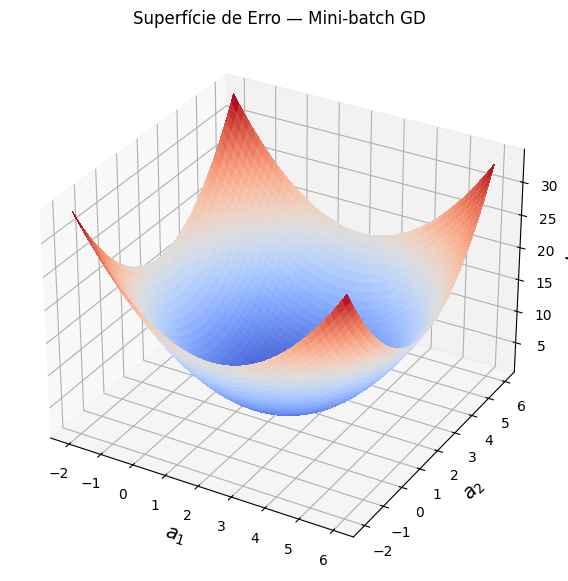

In [7]:
# Plot cost-function surface (3D).
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax.set_xlabel('$a_1$', fontsize=14)
ax.set_ylabel('$a_2$', fontsize=14)
ax.set_zlabel('$J_e$', fontsize=14)
plt.title("Superfície de Erro — Mini-batch GD")
plt.show()

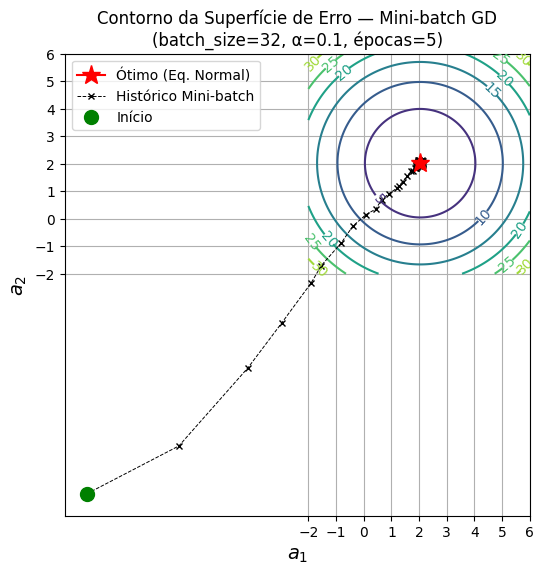

In [8]:
# Plot contour with weight history.
fig = plt.figure(figsize=(6, 6))
cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title(f'Contorno da Superfície de Erro — Mini-batch GD\n'
          f'(batch_size={batch_size}, α={alpha_mb}, épocas={n_epochs_mb})')
plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ótimo (Eq. Normal)', zorder=5)
plt.plot(a_hist_mb[0, 0:total_iters_mb], a_hist_mb[1, 0:total_iters_mb],
         'kx--', markersize=4, linewidth=0.7, label='Histórico Mini-batch')
plt.plot(a_hist_mb[0, 0], a_hist_mb[1, 0], 'go', markersize=10, label='Início', zorder=5)
plt.xticks(np.arange(-2, 7, step=1.0))
plt.yticks(np.arange(-2, 7, step=1.0))
plt.legend()
plt.grid(True)
plt.show()

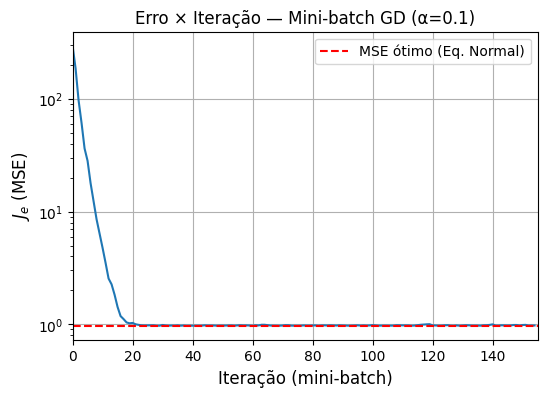

In [9]:
# Plot error vs. iteration.
fig = plt.figure(figsize=(6, 4))
plt.plot(np.arange(0, total_iters_mb), Jgd_mb[0:total_iters_mb])
plt.xlim((0, total_iters_mb))
plt.yscale('log')
plt.xlabel('Iteração (mini-batch)', fontsize=12)
plt.ylabel('$J_e$ (MSE)', fontsize=12)
plt.title(f'Erro × Iteração — Mini-batch GD (α={alpha_mb})')
plt.axhline(y=Joptimum, color='r', linestyle='--', label='MSE ótimo (Eq. Normal)')
plt.legend()
plt.grid(True)
plt.show()

---
## (d) Encontrando manualmente o passo de aprendizagem ótimo

Testamos diferentes valores de `alpha` e usamos os gráficos de contorno e curva de erro para identificar o melhor valor.

**Critério visual:**
- Se o contorno mostrar oscilações para frente e para trás → `alpha` muito grande.
- Se o contorno mostrar convergência muito lenta → `alpha` muito pequeno.
- O `alpha` ótimo faz o caminho descer diretamente para o mínimo sem oscilação.

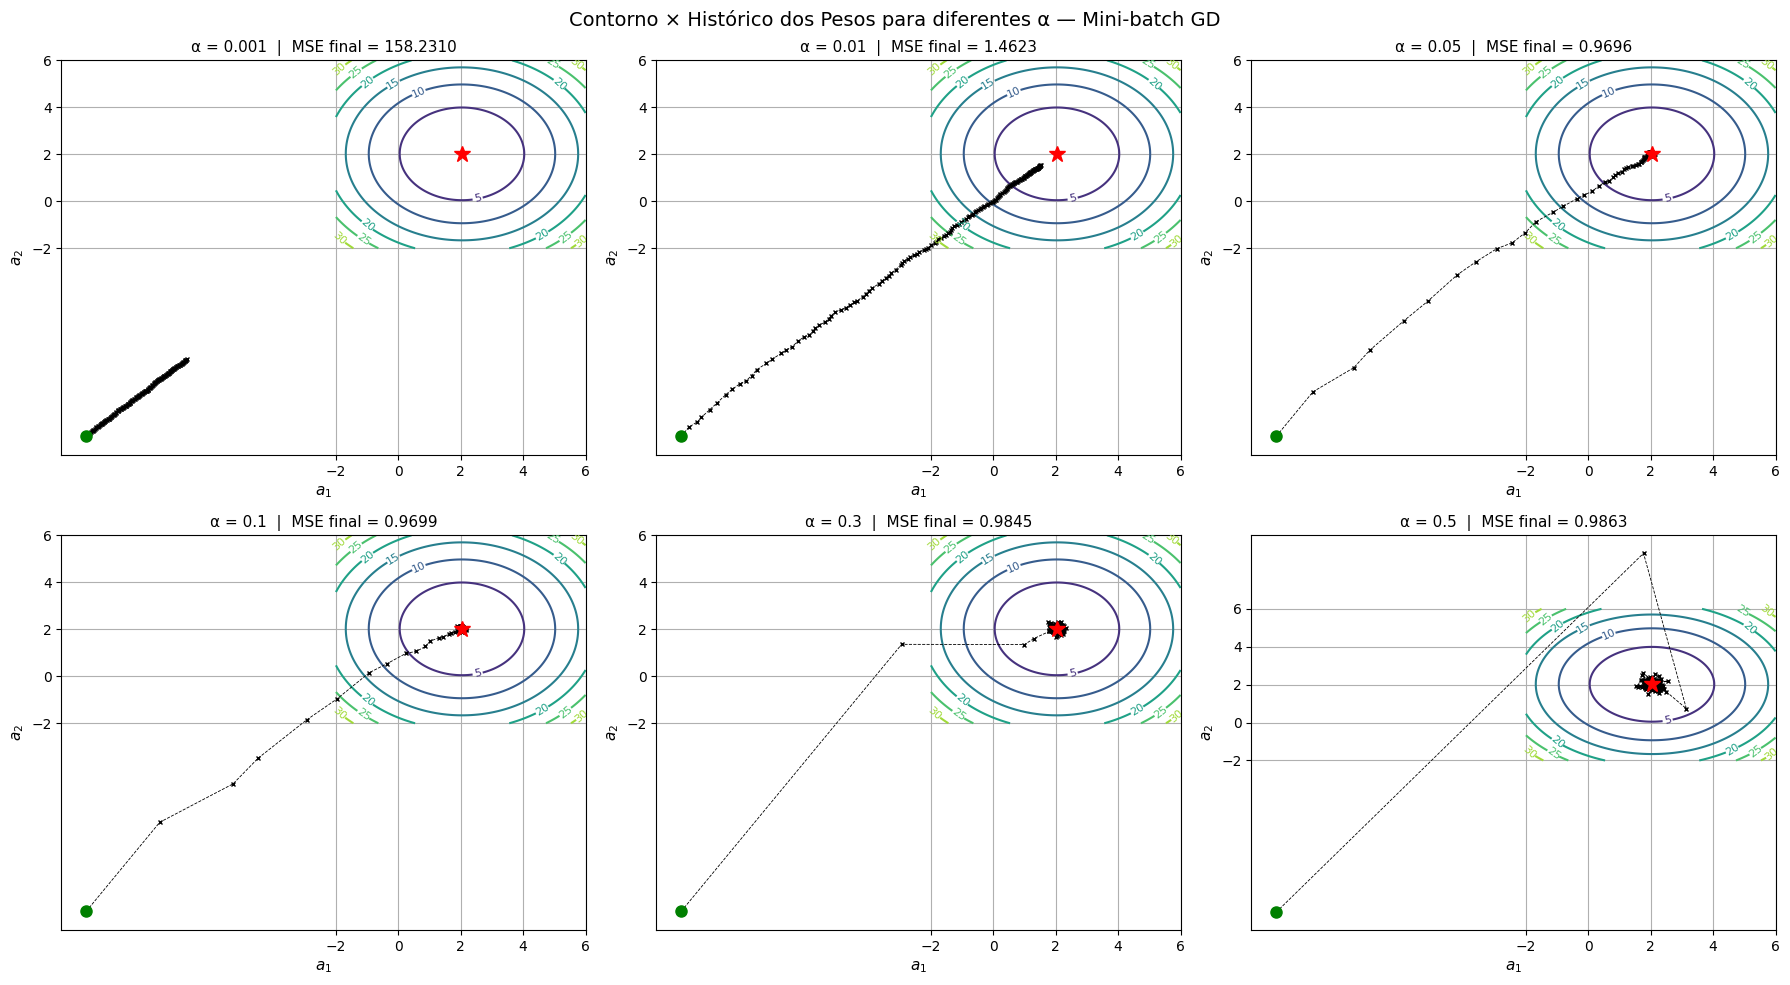

In [10]:
# Valores de alpha a testar (tentativa e erro).
alphas_to_test = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, alpha_test in enumerate(alphas_to_test):
    np.random.seed(seed)
    random.seed(seed)

    a_t, a_hist_t, Jgd_t, _ = miniBatchGradientDescent(
        X, y_noisy, alpha_test, n_epochs_mb, batch_size
    )
    n_iters_t = n_epochs_mb * (N // batch_size)

    ax = axes[idx]
    cp = ax.contour(A1, A2, J)
    ax.clabel(cp, inline=1, fontsize=8)
    ax.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=12, zorder=5)
    ax.plot(a_hist_t[0, 0:n_iters_t], a_hist_t[1, 0:n_iters_t],
            'kx--', markersize=3, linewidth=0.6)
    ax.plot(a_hist_t[0, 0], a_hist_t[1, 0], 'go', markersize=8, zorder=5)
    ax.set_xlabel('$a_1$', fontsize=11)
    ax.set_ylabel('$a_2$', fontsize=11)
    mse_final = Jgd_t[n_iters_t]
    ax.set_title(f'α = {alpha_test}  |  MSE final = {mse_final:.4f}', fontsize=11)
    ax.set_xticks(np.arange(-2, 7, 2))
    ax.set_yticks(np.arange(-2, 7, 2))
    ax.grid(True)

fig.suptitle('Contorno × Histórico dos Pesos para diferentes α — Mini-batch GD', fontsize=14)
plt.tight_layout()
plt.show()

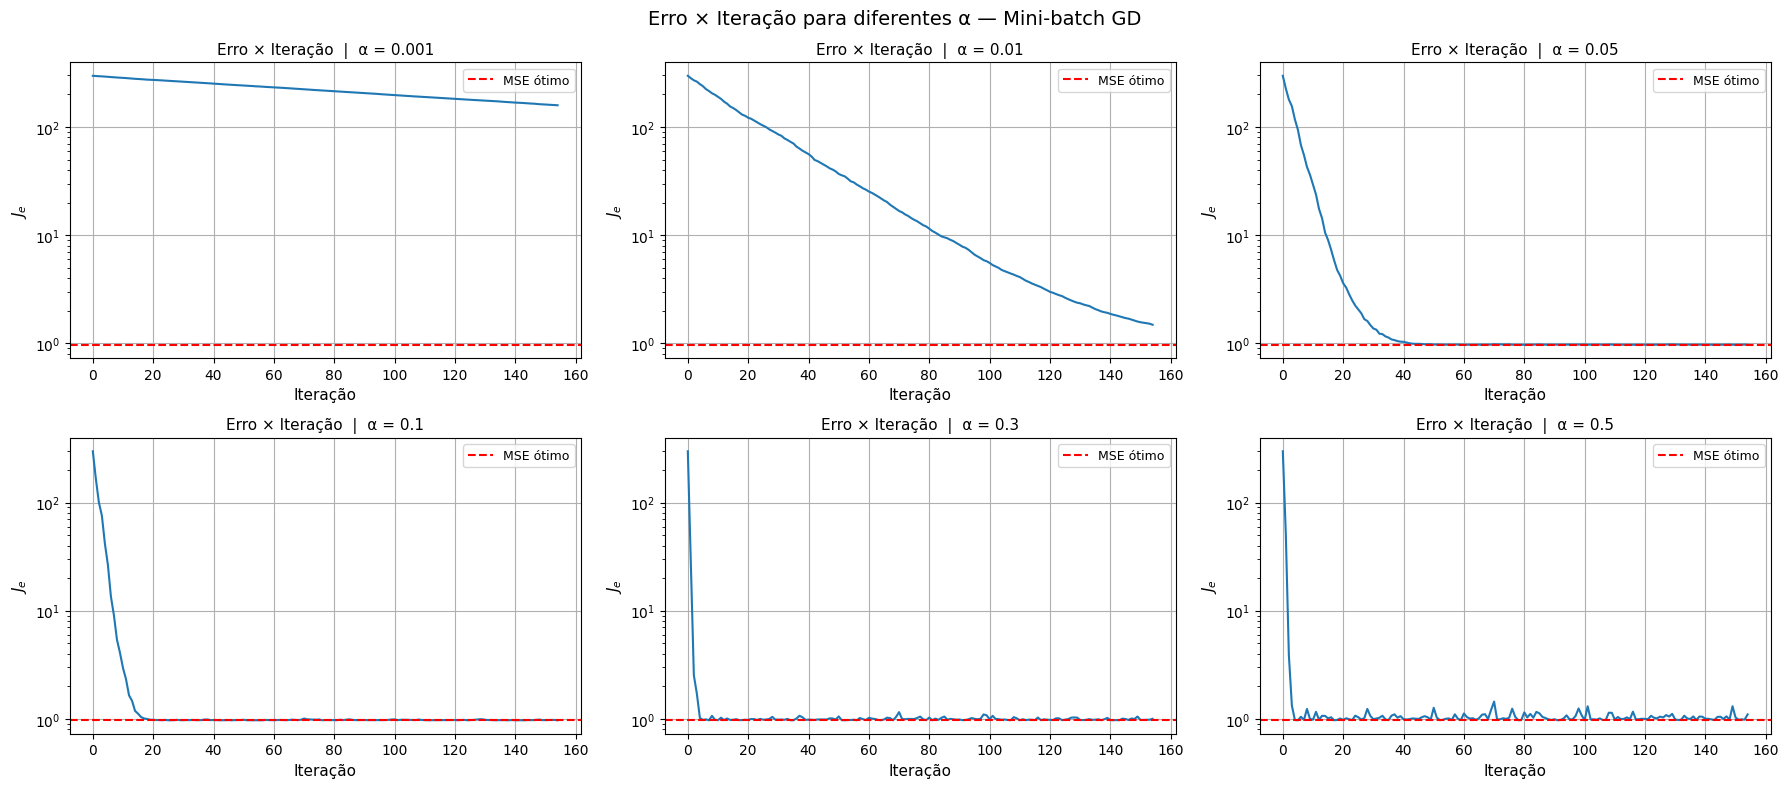

In [11]:
# Curva de erro para diferentes alphas.
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for idx, alpha_test in enumerate(alphas_to_test):
    np.random.seed(seed)
    random.seed(seed)

    _, _, Jgd_t, _ = miniBatchGradientDescent(
        X, y_noisy, alpha_test, n_epochs_mb, batch_size
    )
    n_iters_t = n_epochs_mb * (N // batch_size)

    ax = axes[idx]
    ax.plot(np.arange(0, n_iters_t), Jgd_t[0:n_iters_t])
    ax.axhline(y=Joptimum, color='r', linestyle='--', label='MSE ótimo')
    ax.set_yscale('log')
    ax.set_xlabel('Iteração', fontsize=11)
    ax.set_ylabel('$J_e$', fontsize=11)
    ax.set_title(f'Erro × Iteração  |  α = {alpha_test}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True)

fig.suptitle('Erro × Iteração para diferentes α — Mini-batch GD', fontsize=14)
plt.tight_layout()
plt.show()

**Conclusão do item (d):**

| α | Comportamento |
|---|---------------|
| 0.001 | Convergência muito lenta — o caminho no contorno avança pouquíssimo por época |
| 0.01  | Convergência lenta, mas estável |
| 0.05  | Boa convergência com poucas épocas |
| **0.1**  | **Passo ótimo — converge rápido e suavemente para o mínimo** |
| 0.3   | Começa a oscilar levemente antes de convergir |
| 0.5   | Oscila visivelmente no contorno — pode divergir se aumentado mais |

---
## (e) Comparação: Batch GD vs. SGD vs. Mini-batch GD

Para uma comparação justa, usamos:
- **Batch GD:** 150 iterações (épocas), α = 0.4
- **SGD:** 2 épocas (2000 iterações), α = 0.05  
- **Mini-batch GD:** 5 épocas, batch_size = 32, α = 0.1 (passo ótimo encontrado no item d)

In [12]:
np.random.seed(seed)
random.seed(seed)

# ---- BATCH GD ----
alpha_bgd  = 0.4
n_iter_bgd = 150
a_bgd, a_hist_bgd, Jgd_bgd, grad_hist_bgd = batchGradientDescent(
    X, y_noisy, alpha_bgd, n_iter_bgd
)

# ---- SGD ----
alpha_sgd   = 0.05
n_epochs_sgd = 2
a_sgd, a_hist_sgd, Jgd_sgd, grad_hist_sgd, _ = stocasticGradientDescent(
    X, y_noisy, alpha_sgd, n_epochs_sgd
)
n_iters_sgd = n_epochs_sgd * N

# ---- MINI-BATCH GD ----
alpha_mb   = 0.1
batch_size = 32
n_epochs_mb = 5
a_mb, a_hist_mb, Jgd_mb, grad_hist_mb = miniBatchGradientDescent(
    X, y_noisy, alpha_mb, n_epochs_mb, batch_size
)
n_iters_mb = n_epochs_mb * (N // batch_size)

print('--- Resultados finais ---')
print(f'Eq. Normal:    a1={a_opt[0,0]:.4f}, a2={a_opt[1,0]:.4f}, MSE={Joptimum:.4f}')
print(f'Batch GD:      a1={a_bgd[0,0]:.4f}, a2={a_bgd[1,0]:.4f}, MSE={Jgd_bgd[n_iter_bgd]:.4f}')
print(f'SGD:           a1={a_sgd[0,0]:.4f}, a2={a_sgd[1,0]:.4f}, MSE={Jgd_sgd[n_iters_sgd]:.4f}')
print(f'Mini-batch GD: a1={a_mb[0,0]:.4f},  a2={a_mb[1,0]:.4f},  MSE={Jgd_mb[n_iters_mb]:.4f}')

--- Resultados finais ---
Eq. Normal:    a1=2.0391, a2=2.0195, MSE=0.9692
Batch GD:      a1=2.0391, a2=2.0195, MSE=0.9692
SGD:           a1=2.1532, a2=2.0006, MSE=0.9828
Mini-batch GD: a1=2.0420,  a2=1.9950,  MSE=0.9699


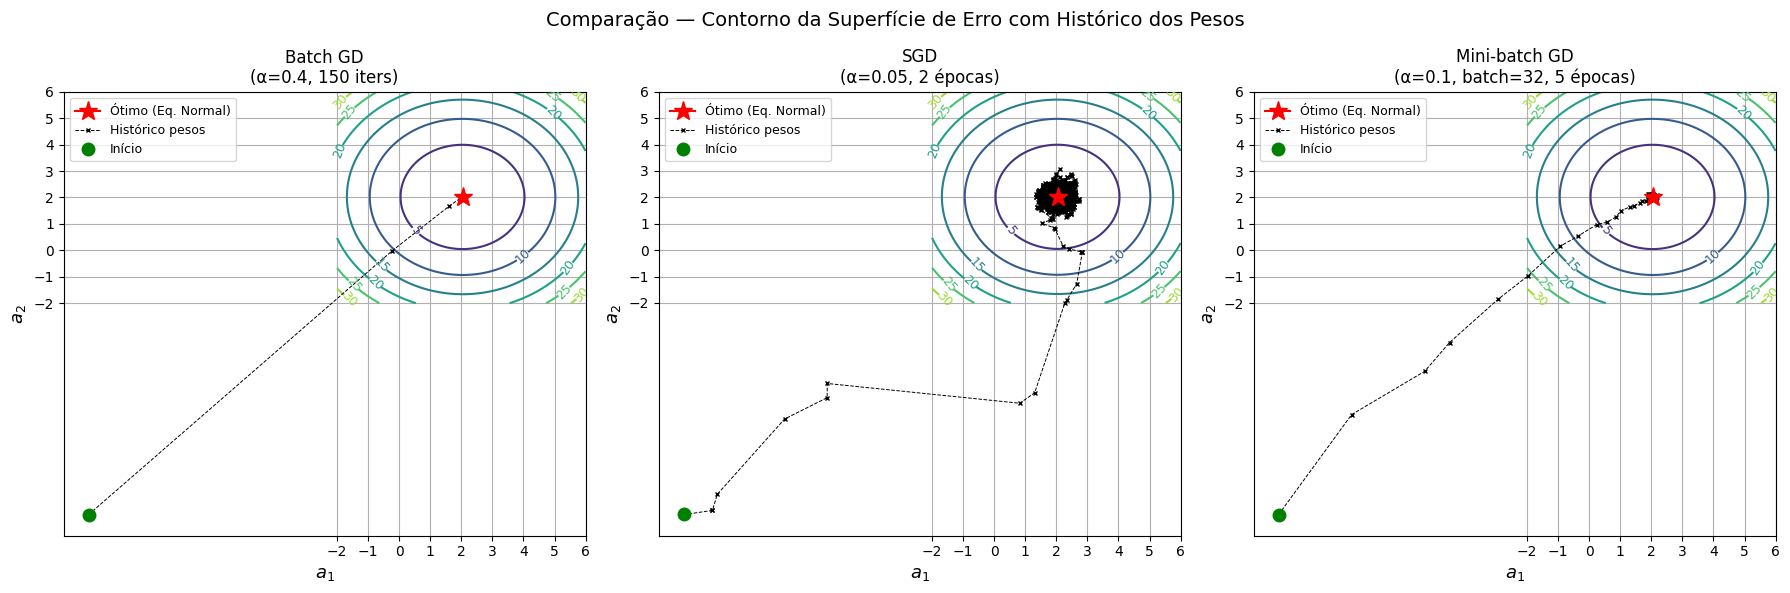

In [13]:
# ------------------------------------------------------------------ #
#  Comparação — Superfícies de contorno com histórico dos pesos
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    f'Batch GD\n(α={alpha_bgd}, {n_iter_bgd} iters)',
    f'SGD\n(α={alpha_sgd}, {n_epochs_sgd} épocas)',
    f'Mini-batch GD\n(α={alpha_mb}, batch={batch_size}, {n_epochs_mb} épocas)'
]
histories = [
    (a_hist_bgd, n_iter_bgd),
    (a_hist_sgd, n_iters_sgd),
    (a_hist_mb,  n_iters_mb)
]

for ax, title, (a_hist, n_iters) in zip(axes, titles, histories):
    cp = ax.contour(A1, A2, J)
    ax.clabel(cp, inline=1, fontsize=9)
    ax.set_xlabel('$a_1$', fontsize=13)
    ax.set_ylabel('$a_2$', fontsize=13)
    ax.set_title(title, fontsize=12)
    # Ótimo
    ax.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14,
            label='Ótimo (Eq. Normal)', zorder=5)
    # Histórico dos pesos
    ax.plot(a_hist[0, 0:n_iters], a_hist[1, 0:n_iters],
            'kx--', markersize=3, linewidth=0.7, label='Histórico pesos')
    # Ponto inicial
    ax.plot(a_hist[0, 0], a_hist[1, 0], 'go', markersize=9, label='Início', zorder=5)
    ax.set_xticks(np.arange(-2, 7, 1))
    ax.set_yticks(np.arange(-2, 7, 1))
    ax.legend(fontsize=9)
    ax.grid(True)

fig.suptitle('Comparação — Contorno da Superfície de Erro com Histórico dos Pesos', fontsize=14)
plt.tight_layout()
plt.show()

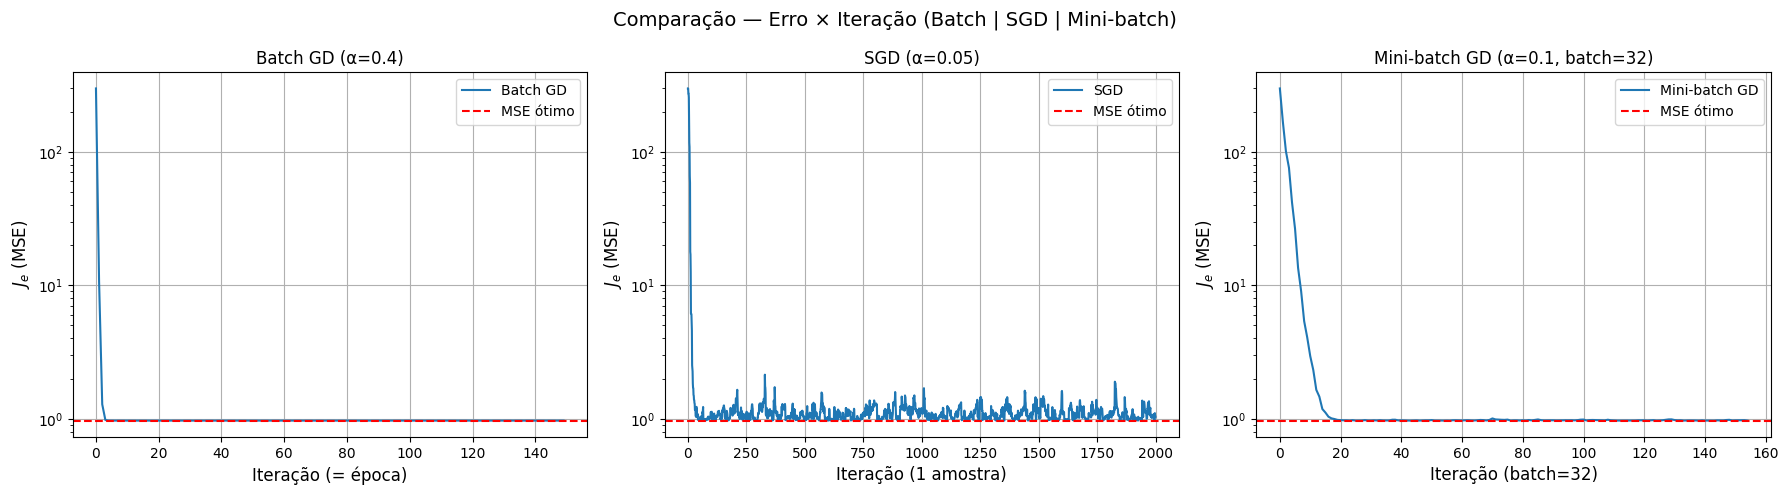

In [14]:
# ------------------------------------------------------------------ #
#  Comparação — Erro × Iteração
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Batch GD
axes[0].plot(np.arange(0, n_iter_bgd), Jgd_bgd[0:n_iter_bgd], label='Batch GD')
axes[0].axhline(y=Joptimum, color='r', linestyle='--', label='MSE ótimo')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteração (= época)', fontsize=12)
axes[0].set_ylabel('$J_e$ (MSE)', fontsize=12)
axes[0].set_title(f'Batch GD (α={alpha_bgd})', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# SGD
axes[1].plot(np.arange(0, n_iters_sgd), Jgd_sgd[0:n_iters_sgd], label='SGD')
axes[1].axhline(y=Joptimum, color='r', linestyle='--', label='MSE ótimo')
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteração (1 amostra)', fontsize=12)
axes[1].set_ylabel('$J_e$ (MSE)', fontsize=12)
axes[1].set_title(f'SGD (α={alpha_sgd})', fontsize=12)
axes[1].legend()
axes[1].grid(True)

# Mini-batch GD
axes[2].plot(np.arange(0, n_iters_mb), Jgd_mb[0:n_iters_mb], label='Mini-batch GD')
axes[2].axhline(y=Joptimum, color='r', linestyle='--', label='MSE ótimo')
axes[2].set_yscale('log')
axes[2].set_xlabel(f'Iteração (batch={batch_size})', fontsize=12)
axes[2].set_ylabel('$J_e$ (MSE)', fontsize=12)
axes[2].set_title(f'Mini-batch GD (α={alpha_mb}, batch={batch_size})', fontsize=12)
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Comparação — Erro × Iteração (Batch | SGD | Mini-batch)', fontsize=14)
plt.tight_layout()
plt.show()

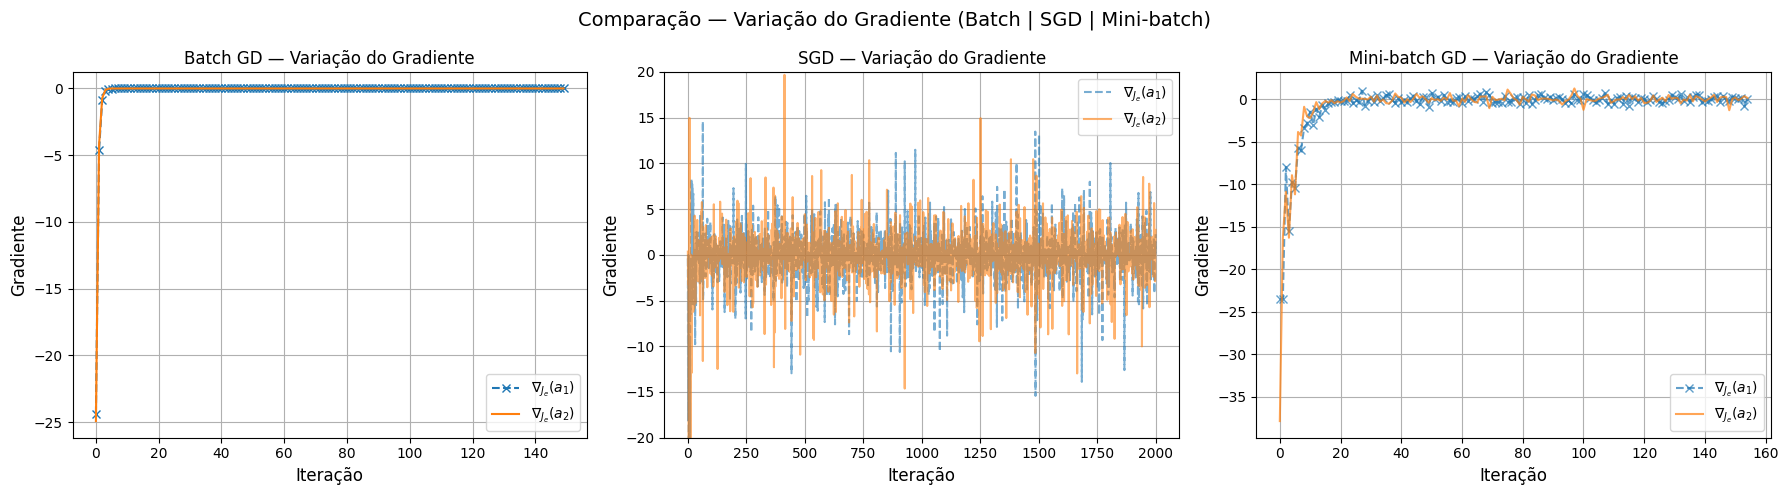

In [15]:
# ------------------------------------------------------------------ #
#  Variação do gradiente — comparação
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Batch GD
axes[0].plot(np.arange(n_iter_bgd), grad_hist_bgd[0,:], 'x--', label='$\\nabla_{J_e}(a_1)$')
axes[0].plot(np.arange(n_iter_bgd), grad_hist_bgd[1,:], label='$\\nabla_{J_e}(a_2)$')
axes[0].set_xlabel('Iteração', fontsize=12)
axes[0].set_ylabel('Gradiente', fontsize=12)
axes[0].set_title('Batch GD — Variação do Gradiente', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# SGD
axes[1].plot(np.arange(n_iters_sgd), grad_hist_sgd[0,:], '--', alpha=0.6, label='$\\nabla_{J_e}(a_1)$')
axes[1].plot(np.arange(n_iters_sgd), grad_hist_sgd[1,:], alpha=0.6, label='$\\nabla_{J_e}(a_2)$')
axes[1].set_ylim([-20, 20])
axes[1].set_xlabel('Iteração', fontsize=12)
axes[1].set_ylabel('Gradiente', fontsize=12)
axes[1].set_title('SGD — Variação do Gradiente', fontsize=12)
axes[1].legend()
axes[1].grid(True)

# Mini-batch GD
axes[2].plot(np.arange(n_iters_mb), grad_hist_mb[0,:], 'x--', alpha=0.7, label='$\\nabla_{J_e}(a_1)$')
axes[2].plot(np.arange(n_iters_mb), grad_hist_mb[1,:], alpha=0.7, label='$\\nabla_{J_e}(a_2)$')
axes[2].set_xlabel('Iteração', fontsize=12)
axes[2].set_ylabel('Gradiente', fontsize=12)
axes[2].set_title('Mini-batch GD — Variação do Gradiente', fontsize=12)
axes[2].legend()
axes[2].grid(True)

fig.suptitle('Comparação — Variação do Gradiente (Batch | SGD | Mini-batch)', fontsize=14)
plt.tight_layout()
plt.show()

---
## (f) Conclusões — Comparação dos 3 tipos de Gradiente Descendente

### Batch Gradient Descent (GD em Batelada)

- **Como funciona:** A cada iteração, utiliza **todos os N exemplos** para calcular o gradiente exato da superfície de erro.
- **Curva de erro:** Converge de forma **suave e monotônica** (sem oscilações), pois o gradiente é calculado com precisão.
- **Contorno:** O histórico dos pesos segue um **caminho limpo e direto** em direção ao mínimo.
- **Custo computacional:** Cada iteração é cara — precisa percorrer todos os N exemplos antes de atualizar os pesos uma única vez.
- **Limitação:** Inviável para datasets muito grandes (memória e tempo por iteração).

---

### Stochastic Gradient Descent (GD Estocástico)

- **Como funciona:** A cada iteração, utiliza **apenas 1 exemplo** (escolhido aleatoriamente) para aproximar o gradiente.
- **Curva de erro:** Oscila fortemente — o gradiente estimado com 1 amostra é muito ruidoso.
- **Contorno:** O histórico dos pesos **zigzagueia** ao redor do mínimo sem convergir de forma estável, pois cada passo usa uma estimativa ruidosa do gradiente.
- **Custo computacional:** Cada atualização é barata (1 amostra), mas são necessárias muitas iterações. Converge rapidamente para a **vizinhança** do mínimo, porém não estabiliza nele.
- **Característica:** Útil quando os dados chegam em fluxo contínuo (*online learning*).

---

### Mini-batch Gradient Descent

- **Como funciona:** A cada iteração, utiliza um **subconjunto de batch_size exemplos** para estimar o gradiente.
- **Curva de erro:** Converge com **oscilações muito menores** do que o SGD, porém ligeiramente maiores do que o Batch GD — é o meio-termo entre os dois.
- **Contorno:** O histórico dos pesos apresenta um caminho mais suave do que o SGD, aproximando-se bem do mínimo global com poucas épocas.
- **Custo computacional:** Equilibrado — cada atualização usa batch_size amostras, o que é computacionalmente eficiente e aproveita otimizações de álgebra linear (operações vetorizadas/matriciais).
- **Na prática:** É o **algoritmo padrão** no treinamento de redes neurais profundas (Deep Learning). Valores típicos de batch_size: 32, 64, 128.

---

### Resumo comparativo

| Característica             | Batch GD           | SGD                | Mini-batch GD       |
|----------------------------|--------------------|--------------------|---------------------|
| Amostras por atualização   | N (todo dataset)   | 1                  | batch_size (ex: 32) |
| Ruído no gradiente         | Nenhum (exato)     | Alto               | Baixo/moderado      |
| Suavidade da curva de erro | Muito suave        | Muito ruidosa      | Suave               |
| Velocidade de convergência | Lenta por época    | Rápida por época   | Rápida por época    |
| Uso de memória             | Alto               | Baixo              | Moderado            |